# ABIDE — Clustering sani vs autistici con distanza f_norm_opt

Pipeline idempotente:
1. Per ogni paziente costruisce un grafo pesato (111 nodi = ROI Harvard-Oxford, archi = correlazione fMRI).
2. Calcola embedding EDRep per ogni nodo (ogni nodo è la propria partizione).
3. Calcola la distanza `f_norm_opt` tra ogni coppia di pazienti → matrice N×N.
4. Divide i pazienti in sani (DX_GROUP=1) e autistici (DX_GROUP=2).
5. Testa se la distanza separa i due gruppi con ClusterNMF + metriche.

> **Idempotenza**: gli embedding e la matrice di distanza vengono salvati in `output_abide_clustering/`.
> Rieseguendo il notebook i risultati vengono caricati dalla cache senza ricalcolare.

In [1]:
import os
import sys
import pickle
import random
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations
from tqdm.auto import tqdm
from sklearn.metrics import normalized_mutual_info_score, silhouette_score, confusion_matrix
from sklearn.decomposition import NMF
from sklearn.cluster import KMeans
from sklearn.manifold import MDS
from nilearn.connectome import ConnectivityMeasure

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from EDRep_main.EDRep import NodeEmbedding

In [12]:
DATA_DIR   = r"C:\Users\Utente\Desktop\progetto vscode\data\abide_data"
TS_DIR     = os.path.join(DATA_DIR, 'ABIDE_pcp', 'cpac', 'nofilt_noglobal')
PHENO_FILE = os.path.join(DATA_DIR, 'ABIDE_pcp', 'Phenotypic_V1_0b_preprocessed1.csv')
OUT_DIR    = os.path.join(os.getcwd(), 'output_abide_clustering')
os.makedirs(OUT_DIR, exist_ok=True)

DIM_EMB   = 32
MIN_TP    = 100
N_ROI     = 111
PARTITION = [[i] for i in range(N_ROI)]   # ogni nodo è la propria partizione

## Funzioni helper

- `create_ABIDE_graph`: carica la serie temporale fMRI, calcola la matrice di correlazione e mantiene solo i pesi positivi.
- `node_embedding`: calcola l'embedding EDRep per ogni nodo del grafo dato il seed per riproducibilità.
- `f_norm_opt`: distanza tra due grafi basata sulle norme delle matrici di Gram degli embedding.
- `ClusterNMF`: clustering tramite NMF + k-means con più restart (pattern da `covasim_distances.ipynb`).

In [3]:
def create_ABIDE_graph(file_name, min_timepoints=MIN_TP):
    """Carica una serie temporale .1D e restituisce la matrice di correlazione sogliata (positivi)."""
    df = pd.read_csv(file_name, sep='\t')
    df.columns = [int(s[1:]) for s in df.columns]
    if len(df) < min_timepoints:
        return None
    conn = ConnectivityMeasure(kind='correlation')
    W = conn.fit_transform([df.values.astype(float)])[0]
    return np.maximum(W, 0)


def delete_nan(g):
    """Sostituisce NaN con 0 nella matrice di adiacenza."""
    for line in g:
        for i in range(len(line)):
            if line[i] != line[i]:  # NaN check
                line[i] = 0
    return g


def node_embedding(g_a, partition_A, dim_embedding, seed=42):
    """Restituisce la lista di sottomatrici di embedding, una per partizione."""
    rdn_state = np.random.get_state()
    random.seed(seed)
    np.random.seed(seed)
    embedding_a = NodeEmbedding(g_a, dim=dim_embedding, k=1, verbose=False)
    X_total = embedding_a.X
    X_list = [X_total[list(nodes), :] for nodes in partition_A]
    np.random.set_state(rdn_state)
    return X_list


def f_norm_opt(embx, emby):
    """Distanza tra grafi via norme di Gram: sqrt(||XtX||^2 + ||YtY||^2 - 2||XtY||^2) / sqrt(2)."""
    x = np.array([e[0] for e in embx])   # (n_roi, dim)
    y = np.array([e[0] for e in emby])
    n00 = np.linalg.norm(x.T @ x)
    n11 = np.linalg.norm(y.T @ y)
    n01 = np.linalg.norm(x.T @ y)
    return np.sqrt(n00**2 + n11**2 - 2 * n01**2) / np.sqrt(2)


def _nmf_kmeans(M, k):
    n = M.shape[0]
    nonzero_vals = M[M > 0]
    Mt = M + np.eye(n) * (np.mean(nonzero_vals) if len(nonzero_vals) > 0 else 1e-6)
    Mt = Mt / np.mean(Mt)
    Y = NMF(n_components=k, max_iter=500, init='random').fit(Mt).components_
    km = KMeans(n_clusters=k, n_init=10)
    km.fit(Y.T)
    return km.labels_, np.abs(km.score(Y.T))


def ClusterNMF(M, k, n_iter=21):
    """Clustering robusto NMF + k-means con n_iter restart, tiene il migliore per inerzia."""
    best_l, best_score = _nmf_kmeans(M, k)
    for _ in range(n_iter - 1):
        l_, score_ = _nmf_kmeans(M, k)
        if score_ < best_score:
            best_score = score_
            best_l = l_
    return best_l


def bw_ratio(D, labels):
    """Between/Within ratio: distanza media inter-gruppo / distanza media intra-gruppo."""
    labels = np.array(labels)
    n = len(labels)
    within  = [D[i, j] for i in range(n) for j in range(i+1, n) if labels[i] == labels[j]]
    between = [D[i, j] for i in range(n) for j in range(i+1, n) if labels[i] != labels[j]]
    return np.mean(between) / np.mean(within) if within and between else np.nan

## Caricamento dati fenotipici e lista file

In [13]:
df_ph = pd.read_csv(PHENO_FILE)
id_to_dx = {str(row['FILE_ID']): int(row['DX_GROUP']) for _, row in df_ph.iterrows()}

path_files = sorted(glob.glob(os.path.join(TS_DIR, '*.1D')))
print(f"File .1D trovati: {len(path_files)}")
print(f"Soggetti nel fenotipico: {len(df_ph)}")

File .1D trovati: 871
Soggetti nel fenotipico: 1112


## Checkpoint 1 — Embedding dei nodi

Per ogni soggetto:
1. Carica la serie temporale fMRI dal file `.1D`.
2. Calcola la matrice di correlazione (111×111) e soglia a pesi positivi.
3. Calcola l'embedding EDRep (dim=32, ogni nodo = partizione a sé).
4. Salva tutto in `embeddings.pkl`.

Se il file esiste, viene caricato direttamente.

In [14]:
EMB_FILE = os.path.join(OUT_DIR, 'embeddings.pkl')

if os.path.exists(EMB_FILE):
    with open(EMB_FILE, 'rb') as f:
        embeddings, valid_ids, labels = pickle.load(f)
    print(f"Cache trovata: {len(valid_ids)} embedding caricati.")
    print(f"  Controlli: {sum(l == 1 for l in labels)}, Autistici: {sum(l == 2 for l in labels)}")
else:
    embeddings = {}
    valid_ids  = []
    labels     = []
    skipped    = 0

    for path in tqdm(path_files, desc='Embedding'):
        fname = os.path.basename(path)

        matched = [(fid, dx) for fid, dx in id_to_dx.items() if fid in fname]
        if not matched:
            skipped += 1
            continue
        fid, dx = matched[0]

        W = create_ABIDE_graph(path)
        if W is None:
            skipped += 1
            continue
        W = delete_nan(W)

        try:
            emb = node_embedding(W, PARTITION, DIM_EMB)
        except Exception as exc:
            print(f"  Saltato {fname}: {exc}")
            skipped += 1
            continue

        embeddings[fid] = emb
        valid_ids.append(fid)
        labels.append(dx)

    with open(EMB_FILE, 'wb') as f:
        pickle.dump((embeddings, valid_ids, labels), f)

    print(f"Calcolati {len(valid_ids)} embedding, saltati {skipped}.")
    print(f"  Controlli: {sum(l == 1 for l in labels)}, Autistici: {sum(l == 2 for l in labels)}")

labels = np.array(labels)
n = len(valid_ids)
print(f"\nSoggetti totali: {n}")

Embedding:   0%|          | 0/871 [00:00<?, ?it/s]

C:\Users\Utente\AppData\Local\Temp\ipykernel_20700\1367359360.py:8: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  W = conn.fit_transform([df.values.astype(float)])[0]
C:\Users\Utente\AppData\Local\Temp\ipykernel_20700\1367359360.py:8: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using stand

Calcolati 846 embedding, saltati 25.
  Controlli: 391, Autistici: 455

Soggetti totali: 846


## Checkpoint 2 — Matrice di distanza N×N

Calcola `f_norm_opt` per ogni coppia di soggetti (triangolo superiore, poi simmetrizza).
Con N≈846 soggetti ci sono ~357 000 coppie: il calcolo è veloce (solo operazioni matriciali).

Se `distance_matrix.npy` esiste viene caricato dalla cache.

In [15]:
DIST_FILE = os.path.join(OUT_DIR, 'distance_matrix.npy')

if os.path.exists(DIST_FILE):
    D = np.load(DIST_FILE)
    print(f"Cache trovata: matrice {D.shape[0]}×{D.shape[1]} caricata.")
else:
    D = np.zeros((n, n))
    pairs = list(combinations(range(n), 2))

    for i, j in tqdm(pairs, desc='Distanze'):
        d = f_norm_opt(embeddings[valid_ids[i]], embeddings[valid_ids[j]])
        D[i, j] = D[j, i] = d

    np.save(DIST_FILE, D)
    print(f"Matrice {n}×{n} calcolata e salvata.")

d_pos = D[D > 0]
print(f"Statistiche distanza: min={d_pos.min():.3f}  mean={d_pos.mean():.3f}  max={d_pos.max():.3f}")

Distanze:   0%|          | 0/357435 [00:00<?, ?it/s]

Matrice 846×846 calcolata e salvata.
Statistiche distanza: min=6.719  mean=18.009  max=41.625


## Analisi esplorativa — distribuzione delle distanze per coppia di gruppi

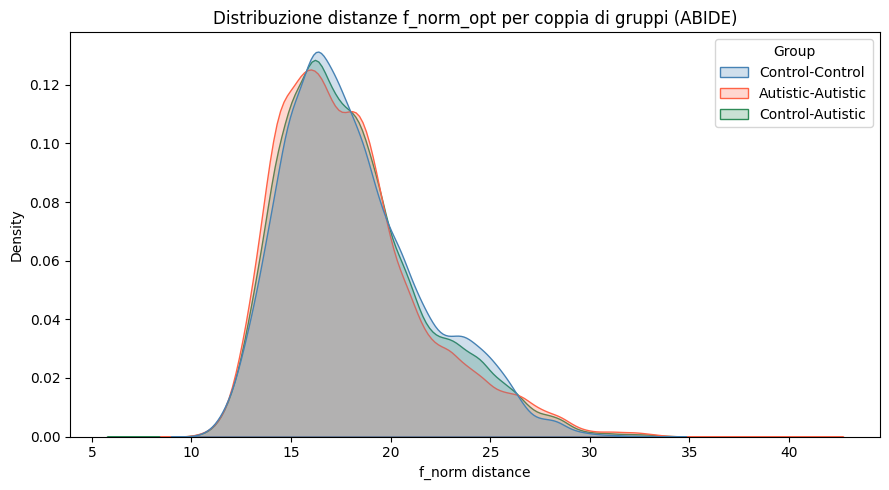

Control-Control  :  mean=18.1066  std=3.5316
Autistic-Autistic:  mean=17.8882  std=3.6559
Control-Autistic :  mean=18.0367  std=3.6097
Separability ratio (mix/within): 1.0022


In [16]:
ctrl_idx = np.where(labels == 1)[0]
aut_idx  = np.where(labels == 2)[0]

d_cc = [D[i, j] for i, j in combinations(ctrl_idx, 2)]
d_aa = [D[i, j] for i, j in combinations(aut_idx, 2)]
d_ca = [D[i, j] for i in ctrl_idx for j in aut_idx]

df_plot = pd.DataFrame({
    'Distance': d_cc + d_aa + d_ca,
    'Group': (['Control-Control'] * len(d_cc) +
               ['Autistic-Autistic'] * len(d_aa) +
               ['Control-Autistic'] * len(d_ca))
})

palette = {'Control-Control': 'steelblue', 'Autistic-Autistic': 'tomato', 'Control-Autistic': 'seagreen'}

plt.figure(figsize=(9, 5))
sns.kdeplot(data=df_plot, x='Distance', hue='Group', fill=True, common_norm=False, palette=palette)
plt.title('Distribuzione distanze f_norm_opt per coppia di gruppi (ABIDE)')
plt.xlabel('f_norm distance')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'kde_distances.png'), dpi=150)
plt.show()

within = 0.5 * np.mean(d_cc) + 0.5 * np.mean(d_aa)
print(f"Control-Control  :  mean={np.mean(d_cc):.4f}  std={np.std(d_cc):.4f}")
print(f"Autistic-Autistic:  mean={np.mean(d_aa):.4f}  std={np.std(d_aa):.4f}")
print(f"Control-Autistic :  mean={np.mean(d_ca):.4f}  std={np.std(d_ca):.4f}")
print(f"Separability ratio (mix/within): {np.mean(d_ca)/within:.4f}")

## Heatmap della matrice di distanza (ordinata per gruppo)

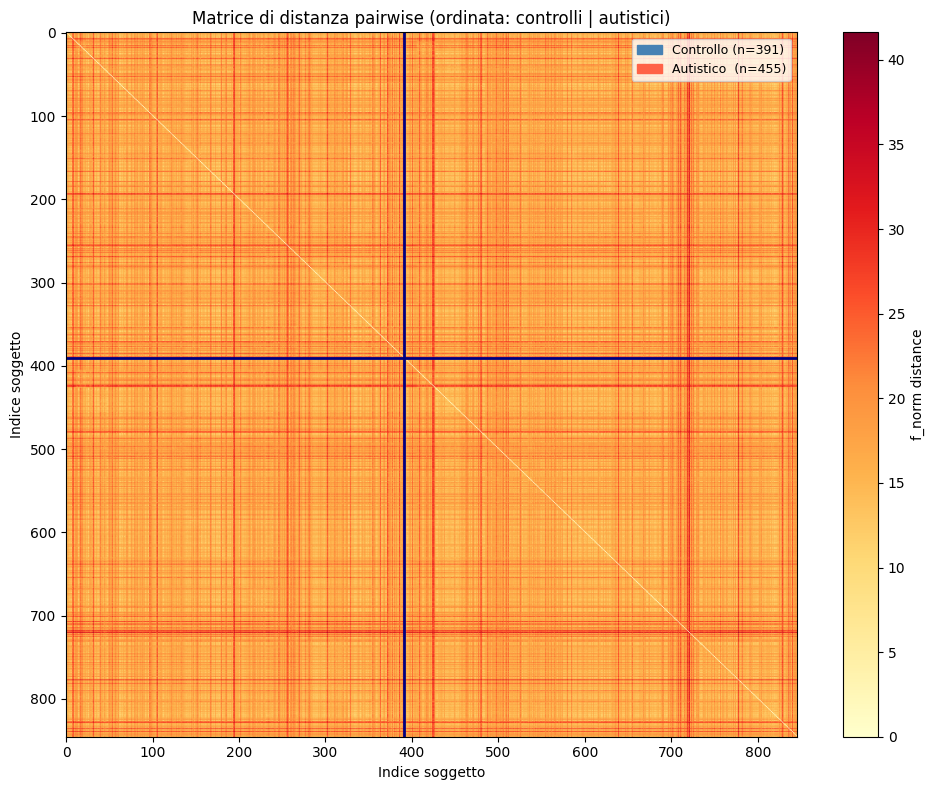

In [17]:
sort_idx = np.concatenate([ctrl_idx, aut_idx])
D_sorted = D[np.ix_(sort_idx, sort_idx)]
n_ctrl = len(ctrl_idx)
n_aut  = len(aut_idx)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(D_sorted, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='f_norm distance')
ax.axhline(n_ctrl - 0.5, color='navy', linewidth=2)
ax.axvline(n_ctrl - 0.5, color='navy', linewidth=2)
ax.set_title('Matrice di distanza pairwise (ordinata: controlli | autistici)')
ax.set_xlabel('Indice soggetto')
ax.set_ylabel('Indice soggetto')

patches = [
    mpatches.Patch(color='steelblue', label=f'Controllo (n={n_ctrl})'),
    mpatches.Patch(color='tomato',    label=f'Autistico  (n={n_aut})')
]
ax.legend(handles=patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'heatmap_distance.png'), dpi=150)
plt.show()

## Clustering con ClusterNMF (k=2)

Applica NMF + k-means (21 restart) sulla matrice di distanza e valuta la qualità del clustering rispetto alla diagnosi vera con:
- **NMI** — Normalized Mutual Information (permutation-invariant)
- **Silhouette Score** — coerenza interna del clustering
- **BW Ratio** — distanza media inter-gruppo / distanza media intra-gruppo
- **Best Accuracy** — accuratezza nel caso migliore di assegnamento etichette

In [18]:
pred_labels = ClusterNMF(D, k=2, n_iter=21)

true_bin = labels - 1  # {1,2} → {0,1}

nmi = normalized_mutual_info_score(true_bin, pred_labels)
sil = silhouette_score(D, pred_labels, metric='precomputed')
bwr = bw_ratio(D, true_bin)

# Accuratezza nella permutazione migliore delle etichette predette
cm0 = confusion_matrix(true_bin, pred_labels)
cm1 = confusion_matrix(true_bin, 1 - pred_labels)
best_acc = max(np.diag(cm0).sum(), np.diag(cm1).sum()) / n

print(f"NMI              : {nmi:.4f}")
print(f"Silhouette Score : {sil:.4f}")
print(f"BW Ratio         : {bwr:.4f}")
print(f"Best accuracy    : {best_acc:.4f}  ({best_acc*100:.1f}%)")

NMI              : 0.0001
Silhouette Score : 0.1350
BW Ratio         : 1.0031
Best accuracy    : 0.5189  (51.9%)


## Visualizzazione MDS 2D

Proiezione della matrice di distanza in 2D tramite MDS (`dissimilarity='precomputed'`).
- Pannello sinistro: colori per diagnosi vera.
- Pannello destro: colori per cluster predetto da ClusterNMF.

c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\manifold\_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\Utente\Desktop\progetto vscode\.venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


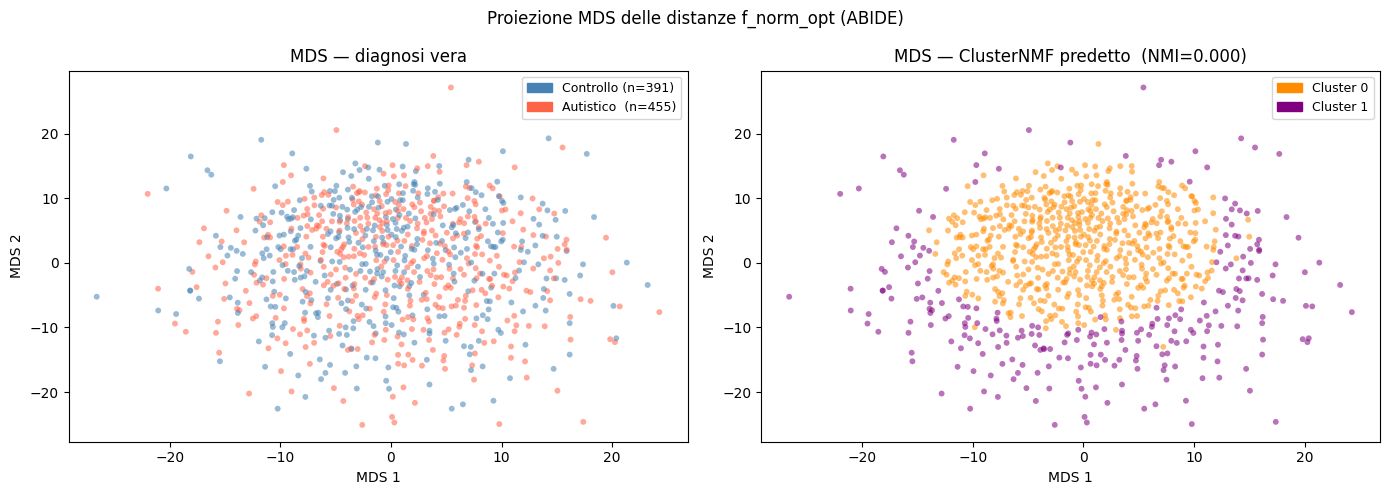

In [19]:
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(D)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pannello sinistro: diagnosi vera
colors_true = np.where(labels == 1, 'steelblue', 'tomato')
axes[0].scatter(coords[:, 0], coords[:, 1], c=colors_true, alpha=0.55, s=18, edgecolors='none')
p1 = mpatches.Patch(color='steelblue', label=f'Controllo (n={n_ctrl})')
p2 = mpatches.Patch(color='tomato',    label=f'Autistico  (n={n_aut})')
axes[0].legend(handles=[p1, p2], fontsize=9)
axes[0].set_title('MDS — diagnosi vera')
axes[0].set_xlabel('MDS 1')
axes[0].set_ylabel('MDS 2')

# Pannello destro: cluster predetto
colors_pred = np.where(pred_labels == 0, 'darkorange', 'purple')
axes[1].scatter(coords[:, 0], coords[:, 1], c=colors_pred, alpha=0.55, s=18, edgecolors='none')
p3 = mpatches.Patch(color='darkorange', label='Cluster 0')
p4 = mpatches.Patch(color='purple',     label='Cluster 1')
axes[1].legend(handles=[p3, p4], fontsize=9)
axes[1].set_title(f'MDS — ClusterNMF predetto  (NMI={nmi:.3f})')
axes[1].set_xlabel('MDS 1')
axes[1].set_ylabel('MDS 2')

plt.suptitle('Proiezione MDS delle distanze f_norm_opt (ABIDE)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'mds_visualization.png'), dpi=150)
plt.show()

## Riepilogo risultati

In [20]:
df_summary = pd.DataFrame([{
    'Soggetti totali':   n,
    'Controlli':         int((labels == 1).sum()),
    'Autistici':         int((labels == 2).sum()),
    'Dim embedding':     DIM_EMB,
    'Mean dist C-C':     f"{np.mean(d_cc):.4f}",
    'Mean dist A-A':     f"{np.mean(d_aa):.4f}",
    'Mean dist C-A':     f"{np.mean(d_ca):.4f}",
    'Separability':      f"{np.mean(d_ca)/within:.4f}",
    'NMI (k=2)':         f"{nmi:.4f}",
    'Silhouette':        f"{sil:.4f}",
    'BW Ratio':          f"{bwr:.4f}",
    'Best accuracy':     f"{best_acc:.4f}",
}])

df_summary.T.rename(columns={0: 'Valore'})

,Valore
Soggetti totali,846
Controlli,391
Autistici,455
Dim embedding,32
Mean dist C-C,18.1066
Mean dist A-A,17.8882
Mean dist C-A,18.0367
Separability,1.0022
NMI (k=2),0.0001
Silhouette,0.1350
